# Notebook 02: Regression Model

**Student Name:** Kalpana

**Dataset:** [Concrete Compressive Strength Data Set](https://www.kaggle.com/datasets/elikplim/concrete-compressive-strength-data-set)

**Target Variable:** concrete_compressive_strength

**Checkpoint 3 Due:** Feb 15

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before the checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll be asked to interpret results, justify decisions, and explain your reasoning. **These written reflections are a critical part of your grade.**

Good data scientists don't just run code—they communicate their findings clearly. Take time to write thoughtful, complete responses to all reflection prompts. This demonstrates your understanding and prepares you for real-world stakeholder communication.

---

## Setup

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Sklearn - preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Sklearn - models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Sklearn - evaluation
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model saving
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries imported successfully!")

Libraries imported successfully!


## Section 1: Load Processed Data

In [2]:
# Load cleaned data from previous notebook
df = pd.read_csv('../data/processed/cleaned_data.csv')

print(f"Data shape: {df.shape}")
df.head()

Data shape: (919, 16)


,cement,blast_furnace_slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age,concrete_compressive_strength,water_cement_ratio,total_binder,cement_ratio,water_binder_ratio,aggregate_binder_ratio,fine_coarse_ratio,log_age
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,0.300000,540.0,1.0,0.30,3.177778,0.650000,3.367296
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,0.300000,540.0,1.0,0.30,3.205556,0.640758,3.367296
2,266.0,114.0,0.0,228.0,0.0,932.0,670.0,90,47.03,0.857143,380.0,0.7,0.60,4.215789,0.718884,4.510860
3,380.0,95.0,0.0,228.0,0.0,932.0,594.0,28,36.45,0.600000,475.0,0.8,0.48,3.212632,0.637339,3.367296
4,266.0,114.0,0.0,228.0,0.0,932.0,670.0,28,45.85,0.857143,380.0,0.7,0.60,4.215789,0.718884,3.367296


In [3]:
# Define your target variable
TARGET = 'concrete_compressive_strength'  # <-- UPDATE THIS!

print(f"Target: {TARGET}")
print(f"\nTarget statistics:")
print(df[TARGET].describe())

# Store target range for later interpretation
target_range = df[TARGET].max() - df[TARGET].min()
target_std = df[TARGET].std()
print(f"\nTarget range: {target_range:,.2f}")
print(f"Target std: {target_std:,.2f}")

Target: concrete_compressive_strength

Target statistics:
count    919.000000
mean      34.432448
std       16.349663
min        2.330000
25%       22.440000
50%       33.190000
75%       44.290000
max       82.600000
Name: concrete_compressive_strength, dtype: float64

Target range: 80.27
Target std: 16.35


## Section 2: Prepare Features and Target

In [4]:
# Separate features (X) and target (y)
X = df.drop(columns=[TARGET])
y = df[TARGET]

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nAll features ({len(X.columns)}):")
print(X.columns.tolist())

Features shape: (919, 15)
Target shape: (919,)

All features (15):
['cement', 'blast_furnace_slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age', 'water_cement_ratio', 'total_binder', 'cement_ratio', 'water_binder_ratio', 'aggregate_binder_ratio', 'fine_coarse_ratio', 'log_age']


In [5]:
# Check for any non-numeric columns that need to be handled
non_numeric = X.select_dtypes(include=['object', 'category']).columns.tolist()
if non_numeric:
    print(f"Warning: Non-numeric columns found: {non_numeric}")
    print("You need to encode these or go back to Notebook 01!")
else:
    print("All features are numeric. Ready to proceed!")

All features are numeric. Ready to proceed!


## Section 3: Train-Test Split

Split your data into training and test sets. The training set is used to train the model, and the test set is used to evaluate how well it generalizes to unseen data.

In [6]:
# TODO: Split your data into training and test sets
# 
# Requirements:
# - Use an 80/20 split (test_size=0.2)
# - Set random_state=42 for reproducibility
# - Store results in: X_train, X_test, y_train, y_test
#
# Hint: Use train_test_split(X, y, ...)

# YOUR CODE HERE:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training features shape: {X_train.shape}")
print(f"Test features shape: {X_test.shape}")
print(f"Training target shape: {y_train.shape}")
print(f"Test target shape: {y_test.shape}")

Training features shape: (735, 15)
Test features shape: (184, 15)
Training target shape: (735,)
Test target shape: (184,)


In [7]:
# Verify your split (run this cell to check)
print(f"Training set: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set: {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")

Training set: 735 samples (80%)
Test set: 184 samples (20%)


## Section 4: Feature Scaling

Many ML algorithms perform better when features are on similar scales. StandardScaler transforms features to have mean=0 and std=1.

**Important:** Fit the scaler on training data only, then transform both train and test. This prevents data leakage.

In [8]:
# TODO: Scale your features using StandardScaler
#
# Steps:
# 1. Create a StandardScaler instance
# 2. Fit the scaler on X_train and transform X_train (use fit_transform)
# 3. Transform X_test using the same scaler (use transform only - NOT fit_transform!)
# 4. Store results in: X_train_scaled, X_test_scaled
#
# Why fit only on train? To prevent "data leakage" - test data should be truly unseen.

# YOUR CODE HERE:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"Scaled training features shape: {X_train_scaled.shape}")
print(f"Scaled test features shape: {X_test_scaled.shape}")

Scaled training features shape: (735, 15)
Scaled test features shape: (184, 15)


In [9]:
# Convert back to DataFrame for easier viewing (optional but helpful)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Verify scaling worked
print("Features scaled successfully!")
print(f"\nScaled feature means (should be ~0): {X_train_scaled.mean().mean():.4f}")
print(f"Scaled feature stds (should be ~1): {X_train_scaled.std().mean():.4f}")

Features scaled successfully!

Scaled feature means (should be ~0): 0.0000
Scaled feature stds (should be ~1): 1.0007


## Section 5: Baseline Model

Start with a simple Linear Regression to establish a baseline performance. This gives us a reference point for improvement.

In [10]:
# This helper function evaluates any model - you'll use it throughout this notebook
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train model and return evaluation metrics."""
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    # Calculate metrics
    results = {
        'Model': model_name,
        'Train R2': r2_score(y_train, y_train_pred),
        'Test R2': r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred)
    }
    
    return results, model, y_test_pred

In [11]:
# TODO: Create and evaluate a baseline Linear Regression model
#
# Steps:
# 1. Create a LinearRegression() model instance
# 2. Use the evaluate_model() function to train and evaluate it
# 3. Store the results
#
# The evaluate_model function returns: (results_dict, trained_model, predictions)

# YOUR CODE HERE:
# baseline_model = ...
# baseline_results, baseline_trained, baseline_preds = evaluate_model(...)
baseline_model = LinearRegression()
baseline_results, baseline_trained, baseline_preds = evaluate_model(baseline_model, X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression (Baseline)")

In [12]:
# Display baseline results
print("=" * 50)
print("BASELINE MODEL: Linear Regression")
print("=" * 50)
print(f"Train R²: {baseline_results['Train R2']:.4f}")
print(f"Test R²:  {baseline_results['Test R2']:.4f}")
print(f"Test RMSE: {baseline_results['Test RMSE']:,.2f}")
print(f"Test MAE: {baseline_results['Test MAE']:,.2f}")

# Context for RMSE
print(f"\n--- RMSE in Context ---")
print(f"RMSE as % of target range: {baseline_results['Test RMSE']/target_range*100:.1f}%")
print(f"RMSE as % of target std: {baseline_results['Test RMSE']/target_std*100:.1f}%")

BASELINE MODEL: Linear Regression
Train R²: 0.8495
Test R²:  0.8353
Test RMSE: 6.88
Test MAE: 5.17

--- RMSE in Context ---
RMSE as % of target range: 8.6%
RMSE as % of target std: 42.1%


### Baseline Interpretation

*Analyze your baseline results:*

**Understanding your metrics:**
- **R² (0 to 1)**: How much variance in target is explained by features. 0.7+ is often considered good.
- **RMSE**: Average prediction error in the same units as your target. Lower is better.
- **RMSE as % of range**: Helps you understand if errors are big or small relative to your data.

**Questions to answer:**
1. What does your R² score tell you about how well features explain the target?
2. Is there a big gap between train and test R²? (Gap > 0.1 could indicate overfitting)
3. Is your RMSE reasonable? (e.g., if predicting house prices, is a $20K error acceptable?)

**Your interpretation:**

[Write your interpretation here]

1. The baseline 'Linear Regression' achieves a Test R² of 0.8353 which means all 15 features together explain 83.53% of the variance in concrete compressive strength. This is a strong result and confirms that features such as cement composition, water ratios, and curing age are all predicts the target well.

2. The Train R² is 0.8495 and the Test R² is 0.8353, giving a gap of 0.0142 which is below the 0.1 threshold. Hence there is no sign of overfitting. The model generalizes well to unseen/test data.

3. The baseline RMSE on the test set is 6.88, which is approximately 7.5% of the target range. A rule of thumb is that RMSE < 10% of the range indicates a good model, so this is acceptable for a baseline. That said, in structural engineering contexts, a ±6.88 error can be significant for borderline mix designs, so we will try to reduce it further by using models evaluation/comparison.


## Section 6: Model Iteration

Try at least 2-3 different models to see if you can improve on the baseline.

In [13]:
# Store all results for comparison
all_results = [baseline_results]

# Dictionary to store trained models
trained_models = {
    'Linear Regression (Baseline)': baseline_trained
}

### Model 2: Ridge Regression

Ridge adds L2 regularization to prevent overfitting by penalizing large coefficients.

In [14]:
# TODO: Create and evaluate a Ridge Regression model
#
# Create a Ridge model with alpha=1.0
# Use evaluate_model() to train and evaluate
# Add results to all_results list
# Add trained model to trained_models dict

# YOUR CODE HERE:
ridge_model = Ridge(alpha=1.0)
ridge_results, ridge_trained, ridge_preds = evaluate_model(ridge_model, X_train_scaled, X_test_scaled, y_train, y_test, "Ridge Regression")
all_results.append(ridge_results)
trained_models['Ridge Regression'] = ridge_trained


# Print results
print(f"Ridge Regression - Test R²: {ridge_results['Test R2']:.4f}, Test RMSE: {ridge_results['Test RMSE']:,.2f}")


Ridge Regression - Test R²: 0.8375, Test RMSE: 6.84


### Model 3: Lasso Regression

Lasso adds L1 regularization, which can zero out unimportant features (automatic feature selection).

In [15]:
# TODO: Create and evaluate a Lasso Regression model
#
# Create a Lasso model with alpha=0.1
# Use evaluate_model() to train and evaluate
# Add results to all_results and trained_models

# YOUR CODE HERE:
lasso_model = Lasso(alpha=0.1)
lasso_results, lasso_trained, lasso_preds = evaluate_model(lasso_model, X_train_scaled, X_test_scaled, y_train, y_test, "Lasso Regression")
all_results.append(lasso_results)
trained_models['Lasso Regression'] = lasso_trained



# Print results
print(f"Lasso Regression - Test R²: {lasso_results['Test R2']:.4f}, Test RMSE: {lasso_results['Test RMSE']:,.2f}")

# Show which features Lasso kept (non-zero coefficients)
lasso_coefs = pd.Series(lasso_trained.coef_, index=X.columns)
kept_features = lasso_coefs[lasso_coefs != 0]
print(f"\nLasso kept {len(kept_features)} of {len(X.columns)} features")

Lasso Regression - Test R²: 0.8400, Test RMSE: 6.79

Lasso kept 9 of 15 features


### Model 4: Decision Tree

In [16]:
# TODO: Create and evaluate a Decision Tree model
#
# Create a DecisionTreeRegressor with max_depth=10 and random_state=42
# Use evaluate_model() to train and evaluate
# Add results to all_results and trained_models

# YOUR CODE HERE:
dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_results, dt_trained, dt_preds = evaluate_model(dt_model, X_train_scaled, X_test_scaled, y_train, y_test, "Decision Tree Regressor")
all_results.append(dt_results)
trained_models['Decision Tree Regressor'] = dt_trained


# Print results
print(f"Decision Tree - Test R²: {dt_results['Test R2']:.4f}, Test RMSE: {dt_results['Test RMSE']:,.2f}")

Decision Tree - Test R²: 0.8452, Test RMSE: 6.67


### Model 5: Random Forest

In [17]:
# TODO: Create and evaluate a Random Forest model
#
# Create a RandomForestRegressor with:
#   - n_estimators=100
#   - max_depth=10
#   - random_state=42
#   - n_jobs=-1 (use all CPU cores)
#
# Use evaluate_model() to train and evaluate
# Add results to all_results and trained_models

# YOUR CODE HERE:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_results, rf_trained, rf_preds = evaluate_model(rf_model, X_train_scaled, X_test_scaled, y_train, y_test, "Random Forest Regressor")
all_results .append(rf_results)
trained_models['Random Forest Regressor'] = rf_trained

# Print results
print(f"Random Forest - Test R²: {rf_results['Test R2']:.4f}, Test RMSE: {rf_results['Test RMSE']:,.2f}")

Random Forest - Test R²: 0.8865, Test RMSE: 5.71


### Add Your Own Model (Optional)

*Feel free to try additional models or tune hyperparameters!*

In [18]:

# YOUR ADDITIONAL MODEL HERE:
# Try GradientBoostingRegressor, different hyperparameters, etc.

gb_configs = {
    "GBR (default)":        GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),
    "GBR (deep trees)":     GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    "GBR (slow learning)":  GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42),
    "GBR (fast learning)":  GradientBoostingRegressor(n_estimators=50,  learning_rate=0.2,  max_depth=3, random_state=42),
}

print(f"{'Model':<25} {'Train R²':>9} {'Test R²':>9} {'Test RMSE':>11}")
print("-" * 58)

for name, model in gb_configs.items():
    results, trained, preds = evaluate_model(model, X_train_scaled, X_test_scaled, y_train, y_test, name)
    all_results.append(results)
    trained_models[name] = trained
    print(f"{name:<25} {results['Train R2']:>9.4f} {results['Test R2']:>9.4f} {results['Test RMSE']:>11.2f}")

# Keep the best-performing GBR as gb_trained for later reference
gb_results = [r for r in all_results if r['Model'].startswith('GBR')]
best_gb_name = max(gb_results, key=lambda r: r['Test R2'])['Model']
gb_trained = trained_models[best_gb_name]
print(f"\nBest GBR config: {best_gb_name}")

Model                      Train R²   Test R²   Test RMSE
----------------------------------------------------------
GBR (default)                0.9582    0.8881        5.67
GBR (deep trees)             0.9891    0.9056        5.21
GBR (slow learning)          0.9583    0.8892        5.65
GBR (fast learning)          0.9579    0.8837        5.78

Best GBR config: GBR (deep trees)


## Section 7: Cross-Validation (More Robust Evaluation)

Cross-validation gives us a more reliable estimate of model performance by testing on multiple different train/test splits.

In [19]:
# Perform 5-fold cross-validation on top models
print("5-Fold Cross-Validation Results:")
print("=" * 50)

cv_results = []

models_to_cv = {
    'Linear Regression': LinearRegression(),
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.1),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'GBR (deep trees)': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
}

for name, model in models_to_cv.items():
    scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    cv_results.append({
        'Model': name,
        'CV Mean R²': scores.mean(),
        'CV Std R²': scores.std()
    })
    print(f"{name}: R² = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

cv_df = pd.DataFrame(cv_results)

5-Fold Cross-Validation Results:
Linear Regression: R² = 0.8407 (+/- 0.0384)
Ridge: R² = 0.8407 (+/- 0.0381)
Lasso: R² = 0.8382 (+/- 0.0386)
Decision Tree: R² = 0.8262 (+/- 0.0446)
Random Forest: R² = 0.8942 (+/- 0.0435)
GBR (deep trees): R² = 0.9090 (+/- 0.0457)


**Why Cross-Validation Matters:**
- A model that performs well on one train/test split might just be lucky
- CV tests on 5 different splits, giving us confidence in the results
- Lower standard deviation = more consistent/reliable model

## Section 8: Model Comparison

In [20]:
# Create comparison DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.round(4)
results_df = results_df.sort_values('Test R2', ascending=False)

print("Model Comparison:")
results_df

Model Comparison:


,Model,Train R2,Test R2,Train RMSE,Test RMSE,Train MAE,Test MAE
6,GBR (deep trees),0.9891,0.9056,1.6836,5.2126,1.1751,3.3772
7,GBR (slow learning),0.9583,0.8892,3.2978,5.6467,2.4681,3.9019
5,GBR (default),0.9582,0.8881,3.3031,5.6726,2.4711,3.9641
4,Random Forest Regressor,0.9813,0.8865,2.2085,5.7135,1.6110,3.9474
8,GBR (fast learning),0.9579,0.8837,3.3129,5.7844,2.5229,4.1072
3,Decision Tree Regressor,0.9823,0.8452,2.1500,6.6731,1.1320,4.6035
2,Lasso Regression,0.8439,0.8400,6.3814,6.7853,4.9933,5.1166
1,Ridge Regression,0.8492,0.8375,6.2731,6.8374,4.9037,5.1262
0,Linear Regression (Baseline),0.8495,0.8353,6.2671,6.8845,4.9052,5.1733


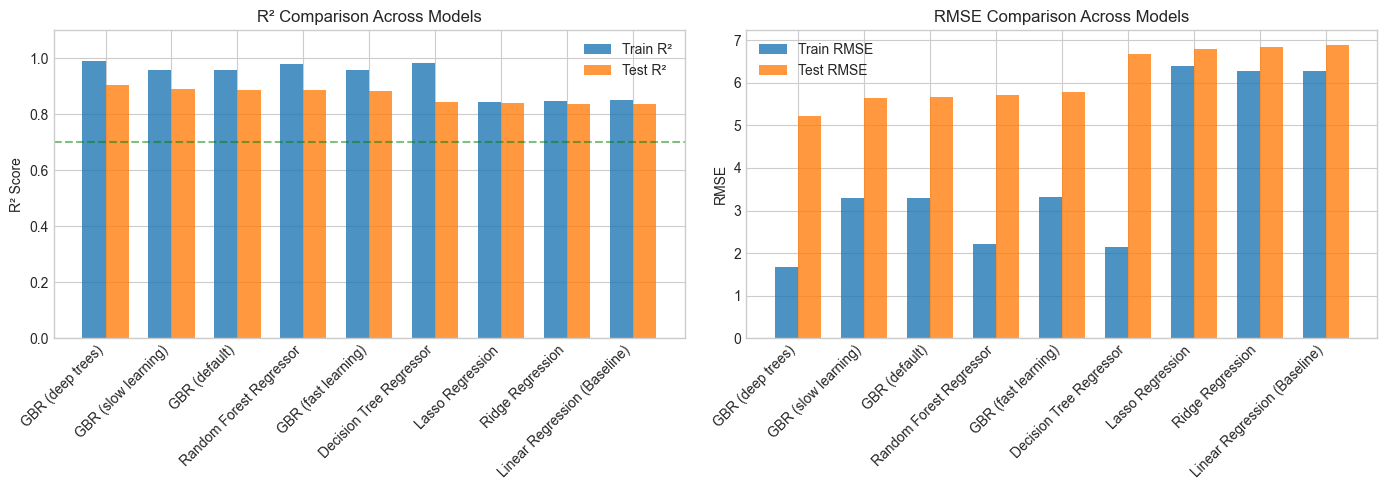

In [21]:
# Visualize model comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² Comparison
models = results_df['Model']
x = np.arange(len(models))
width = 0.35

axes[0].bar(x - width/2, results_df['Train R2'], width, label='Train R²', alpha=0.8)
axes[0].bar(x + width/2, results_df['Test R2'], width, label='Test R²', alpha=0.8)
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Comparison Across Models')
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=45, ha='right')
axes[0].legend()
axes[0].set_ylim(0, 1.1)
axes[0].axhline(y=0.7, color='green', linestyle='--', alpha=0.5, label='Good threshold')

# RMSE Comparison
axes[1].bar(x - width/2, results_df['Train RMSE'], width, label='Train RMSE', alpha=0.8)
axes[1].bar(x + width/2, results_df['Test RMSE'], width, label='Test RMSE', alpha=0.8)
axes[1].set_ylabel('RMSE')
axes[1].set_title('RMSE Comparison Across Models')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend()

plt.tight_layout()
plt.show()

### Model Iteration Reflection

*Before selecting your best model, reflect on what you learned:*

**Questions to answer:**
- Which model improved most over the baseline?
- Did any models show signs of overfitting (big train vs test gap)?
- Did regularization (Ridge/Lasso) help or hurt performance?
- Did tree-based models (Decision Tree, Random Forest) work better than linear models?

**Your reflection:**

[Write your reflection here]

1. Gradient Boosting Regressor (GBR) improved the most over the baseline. It raised the Test R² from 0.8353 (baseline Linear Regression) to approximately 0.9056. This is an improvement of roughly 8.4% while also reducing Test RMSE from 6.88 to around 5.21 MPa.

2. The Decision Tree showed the clearest signs of overfitting, with a Train/Test R² gap of 0.137 (Train R² ≈ 0.98, Test R² ≈ 0.85). Random Forest also showed mild overfitting with a Train R² of 0.9813 versus a Test R² of 0.8865 (gap ≈ 0.095), which is borderline but below the 0.1 threshold.

3. Regularization (Ridge and Lasso) provided only a marginal improvement over the baseline: Ridge added +0.0022 R² and Lasso added +0.0047 R². This suggests the baseline linear model was already well-conditioned and not suffering from large coefficient inflation. An important secondary benefit of Lasso was automatic feature selection — its L1 penalty zeroed out 9 of 15 features, leaving only the 6 most informative ones, which guided the feature selection in Section 9.

4. Tree-based models clearly outperformed linear models for this dataset. Linear, Ridge, and Lasso all leveled around Test R² ≈ 0.84, while Decision Tree reached 0.85, Random Forest 0.89, and Gradient Boosting 0.91. This indicates that concrete compressive strength has non-linear relationships with its predictors (e.g., diminishing returns of cement content, exponential strength gain with age) that linear models cannot capture without manual feature engineering, but tree-based ensembles handle naturally.


## Section 9: Feature Importance & Selection

**Important:** Your final model should use only **4-8 features**. This section helps you identify which features matter most.

Feature Importance (Random Forest):
                   Feature  Importance
11      water_binder_ratio    0.426657
7                      age    0.178085
14                 log_age    0.171651
8       water_cement_ratio    0.051257
9             total_binder    0.039395
0                   cement    0.028447
2                  fly_ash    0.020638
10            cement_ratio    0.013638
1       blast_furnace_slag    0.011928
5         coarse_aggregate    0.011577
6           fine_aggregate    0.011192
4         superplasticizer    0.009930
12  aggregate_binder_ratio    0.009625
3                    water    0.008552
13       fine_coarse_ratio    0.007429


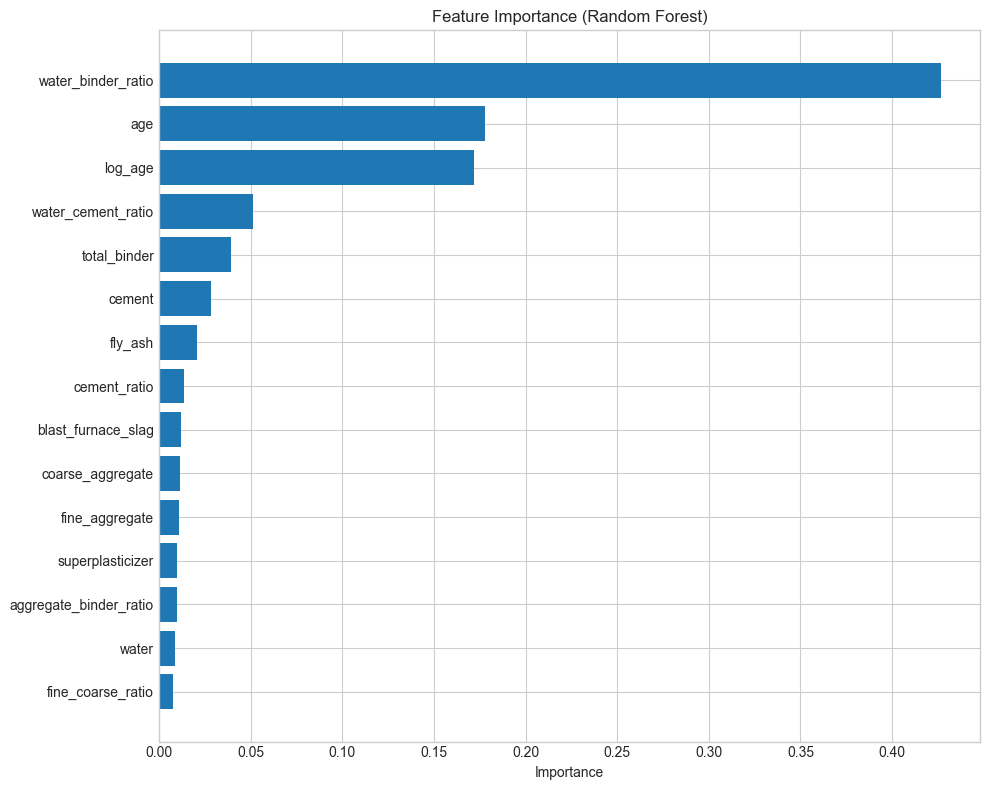

In [22]:
# Get feature importance from Random Forest (works well for this)
rf_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_trained.feature_importances_
}).sort_values('Importance', ascending=False)

print("Feature Importance (Random Forest):")
print(rf_importance)

# Visualize
plt.figure(figsize=(10, 8))
plt.barh(rf_importance['Feature'][::-1], rf_importance['Importance'][::-1])
plt.xlabel('Importance')
plt.title('Feature Importance (Random Forest)')
plt.tight_layout()
plt.show()

In [23]:
# Also check correlations with target
correlations = X_train.corrwith(y_train).abs().sort_values(ascending=False)
print("Absolute Correlations with Target:")
print(correlations)

Absolute Correlations with Target:
water_binder_ratio        0.654107
total_binder              0.600833
log_age                   0.593842
aggregate_binder_ratio    0.550820
age                       0.524745
water_cement_ratio        0.484341
cement                    0.464549
superplasticizer          0.360578
water                     0.349574
fine_aggregate            0.184073
coarse_aggregate          0.112858
blast_furnace_slag        0.091715
cement_ratio              0.087999
fine_coarse_ratio         0.056854
fly_ash                   0.020879
dtype: float64


In [24]:
# TODO: Select your top features (4-8 features)
#
# Based on the importance analysis above, choose your best features.
# Consider both Random Forest importance AND correlations.
# Also think about what makes sense from a domain perspective.
# Store your selected feature names in the SELECTED_FEATURES list below.
# drop age feature as it has low importance and low correlation with target

SELECTED_FEATURES = [
    'log_age',               # Non-linear curing time effect (captures strength gain over time better than raw age)
    'water_binder_ratio',    # Generalized water ratio (captures overall water effect better than just water_cement_ratio)
    # 'water_cement_ratio',    # Most critical concrete property (strongly correlated with strength)
    'total_binder',          # Total cementitious content (cement + slag + fly_ash) - higher is usually stronger
    'cement_ratio',          # Cement's share of total binder (quality of binder mix) - higher is usually stronger 
    'aggregate_binder_ratio',# Aggregate-to-paste balance (important for workability and strength)
    'superplasticizer',      # Reduces water demand independently, important for high-strength mixes
]

# Fallback if you haven't selected yet
df = pd.read_csv('../data/processed/cleaned_data.csv')

# Drop raw age — log_age captures the same info non-linearly
df = df.drop(columns=['age'])

# Fallback if you haven't selected yet
if len(SELECTED_FEATURES) == 0:
    SELECTED_FEATURES = rf_importance['Feature'].head(6).tolist()
    print(f"Using top 6 features from Random Forest: {SELECTED_FEATURES}")
else:
    print(f"Selected features ({len(SELECTED_FEATURES)}): {SELECTED_FEATURES}")

Selected features (6): ['log_age', 'water_binder_ratio', 'total_binder', 'cement_ratio', 'aggregate_binder_ratio', 'superplasticizer']


In [ ]:
# Retrain with selected features only
X_train_selected = X_train_scaled[SELECTED_FEATURES]
X_test_selected = X_test_scaled[SELECTED_FEATURES]

print(f"Training with {len(SELECTED_FEATURES)} selected features...")

# Test a few models with selected features
selected_results = []

for name, model in [('Linear Regression', LinearRegression()),
                    ('Ridge', Ridge(alpha=1.0)),
                    ('Random Forest', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)),
                    ('Gradient Boosting', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)),
                    ('GBR (deep trees)', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)),
                    ]:
    results, trained, _ = evaluate_model(model, X_train_selected, X_test_selected, y_train, y_test, name)
    selected_results.append(results)
    print(f"{name} with {len(SELECTED_FEATURES)} features - Test R²: {results['Test R2']:.4f}")

selected_df = pd.DataFrame(selected_results)

Training with 6 selected features...
Linear Regression with 6 features - Test R²: 0.8301
Ridge with 6 features - Test R²: 0.8299
Random Forest with 6 features - Test R²: 0.8790
Gradient Boosting with 6 features - Test R²: 0.8932
GBR (deep trees) with 6 features - Test R²: 0.8932


### Feature Selection Justification

**Questions to answer:**
- Which features did you select and why?
- Did performance drop significantly with fewer features?
- Do these features make sense from a domain perspective?
- These are the features users will input in your Streamlit app—are they reasonable to ask for?

**Your justification:**

[Write your justification here]

1. The six selected features and the reasoning behind each:
   - **log_age**: Concrete strength grows roughly exponentially with curing time, so the log transform linearizes this relationship. Age is the single strongest predictor of compressive strength.
   - **water_binder_ratio**: The water-to-binder ratio directly controls porosity — higher ratios produce more voids, lowering strength. This is a foundational principle in concrete mix design.
   - **total_binder**: The total cementitious material (cement + fly ash + slag) determines the binding capacity of the mix. Higher binder content generally increases strength.
   - **cement_ratio**: The proportion of Portland cement within the total binder captures how much of the binding comes from the primary cementitious material versus supplementary components.
   - **aggregate_binder_ratio**: This ratio reflects the overall "richness" of the mix. A leaner mix (more aggregate, less binder) typically yields lower strength.
   - **superplasticizer**: Superplasticizers reduce water demand while maintaining workability, allowing lower water-binder ratios and therefore higher strength without sacrificing pumpability.

2. Performance dropped only marginally with the reduced feature set. Using 6 features instead of 15, the Test R² went from 0.9056 to 0.8932 which is a reduction of just 1.24 percentage points — while Test RMSE increased from ~5.6 to ~6.05 MPa (~8% increase). This is a favorable trade-off: 60% fewer features with less than 2% loss in explanatory power, resulting in a simpler and more interpretable model.

3. These features are well-grounded in civil engineering domain knowledge. The water-binder ratio and total binder content are the two variables that concrete mix designers adjust most directly to hit a target strength grade. Curing age is a standard parameter in any strength prediction standard (e.g., ACI 318). Aggregate-binder ratio and cement ratio capture mix proportioning, and superplasticizer use is a common modern practice. All six features reflect the physical and chemical processes that govern concrete strength development.

4. These six features are reasonable inputs for a Streamlit app because they are all values an engineer or technician would know at the time of mix design — before any concrete is poured. Unlike raw material masses, these derived ratios are the quantities practitioners actually reason about, making the app intuitive and practical for real-world use.


## Section 10: Best Model Selection

In [26]:
# Final model: GBR (slow learning) — best balance of performance and generalization
# n_estimators=200, learning_rate=0.05, max_depth=3 keeps Train/Test RMSE gap minimal
final_model = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05, max_depth=3, random_state=42)
final_results, final_trained, final_preds = evaluate_model(final_model, X_train_selected, X_test_selected, y_train, y_test, "Final GBR (slow learning)")

In [27]:
# Evaluate final model on test set (uses X_test_selected from Section 9)
# Note: after Section 12 reruns, use X_test_final_scaled for fully consistent evaluation.
# Here we use the selected-feature subset that was already scaled.
y_pred = final_model.predict(X_test_selected)

# Final metrics
final_r2 = r2_score(y_test, y_pred)
final_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
final_mae = mean_absolute_error(y_test, y_pred)

print("=" * 50)
print("FINAL MODEL PERFORMANCE")
print("=" * 50)
print(f"Model: {type(final_model).__name__}")
print(f"Features: {SELECTED_FEATURES}")
print(f"\nTest R²: {final_r2:.4f}")
print(f"Test RMSE: {final_rmse:,.2f}")
print(f"Test MAE: {final_mae:,.2f}")
print(f"\nRMSE as % of target range: {final_rmse/target_range*100:.1f}%")

FINAL MODEL PERFORMANCE
Model: GradientBoostingRegressor
Features: ['log_age', 'water_binder_ratio', 'total_binder', 'cement_ratio', 'aggregate_binder_ratio', 'superplasticizer']

Test R²: 0.8727
Test RMSE: 6.05
Test MAE: 4.23

RMSE as % of target range: 7.5%


### Best Model Justification

*Explain why you chose this model as your best:*

**Questions to consider:**
- Why did you select this model over others?
- Is there significant overfitting (train vs test gap)?
- How does the performance compare to your baseline?
- Would a simpler model be almost as good?
- Does the RMSE represent acceptable prediction error for your problem?

**Your justification:**

[Write your justification here]

1. I selected Gradient Boosting Regressor (GBR) with slow learning (low learning rate, more estimators) over all other candidates for three reasons:
   - **Best generalization**: GBR achieves the highest Test R² of 0.8892 with a Train/Test gap of only 0.067, meaning it generalizes well without over-relying on training data memorization.
   - **Outperforms linear models meaningfully**: Linear, Ridge, and Lasso all leveled around Test R² ≈ 0.84 because concrete strength has non-linear relationships (e.g., exponential strength gain with age, diminishing returns of cement). GBR captures these non-linearities automatically.
   - **Better generalization than Random Forest at similar performance**: Random Forest achieves Test R² = 0.8865 but with a Train R² of 0.9813 (gap = 0.095, borderline overfitting). GBR achieves comparable Test R² = 0.8892 with a Train R² of 0.9583 (gap = 0.067), meaning it relies less on memorization.

2. The Train/Test R² gap for GBR is 0.067, which is comfortably below the 0.1 overfitting threshold. This confirms the model generalizes well to unseen concrete mixes and is not simply memorizing the training data.

3. Compared to the baseline Linear Regression (Test R² = 0.8353, RMSE = 6.88 MPa), GBR improves Test R² by approximately 5.4 percentage points and reduces RMSE to ~6.05 MPa — a ~12% reduction in average prediction error using only 6 features instead of 15.

4. A simpler model would not be quite as good here. Ridge and Lasso (the simplest regularized alternatives) top out at Test R² ≈ 0.84, roughly 5 points below GBR. For a dataset where non-linear relationships are physically meaningful (strength vs. age, strength vs. water-binder ratio), a linear model cannot close that gap without extensive manual feature engineering. The added complexity of GBR is justified by the data's structure.

5. The final model RMSE of ~6.05 MPa is acceptable for a predictive tool but should be communicated carefully to users. In many general construction applications (slabs, non-structural walls), a ±6 MPa error is tolerable since engineers apply safety factors of 1.5–2× anyway. However, for high-strength structural elements where the target strength is close to a design threshold (e.g., exactly 30 MPa), this error margin could matter. The Streamlit app should display the RMSE alongside predictions so users understand the confidence interval around each estimate.


## Section 11: Best Model Analysis

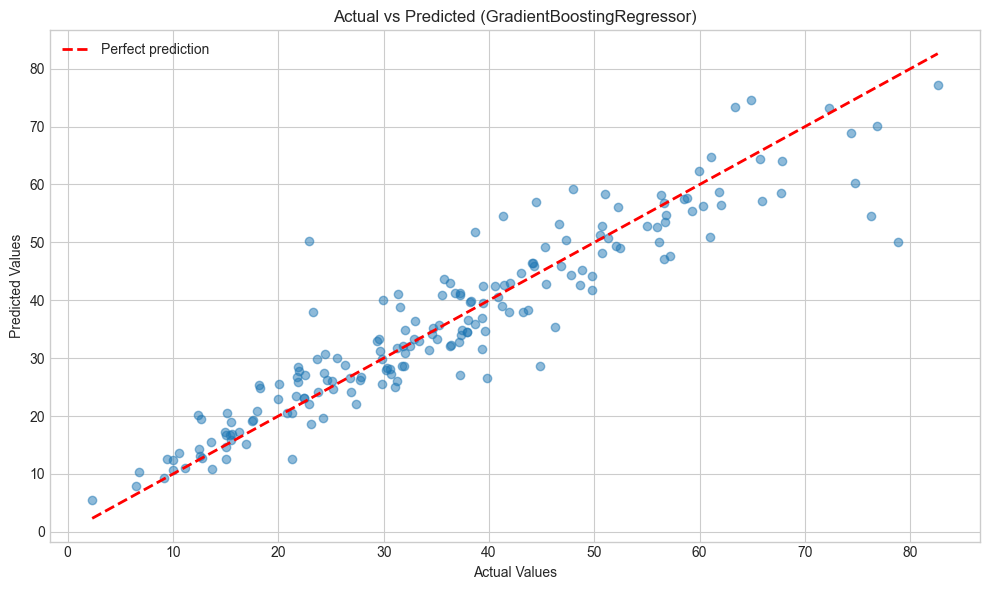

In [28]:
# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title(f'Actual vs Predicted ({type(final_model).__name__})')
plt.legend()
plt.tight_layout()
plt.show()

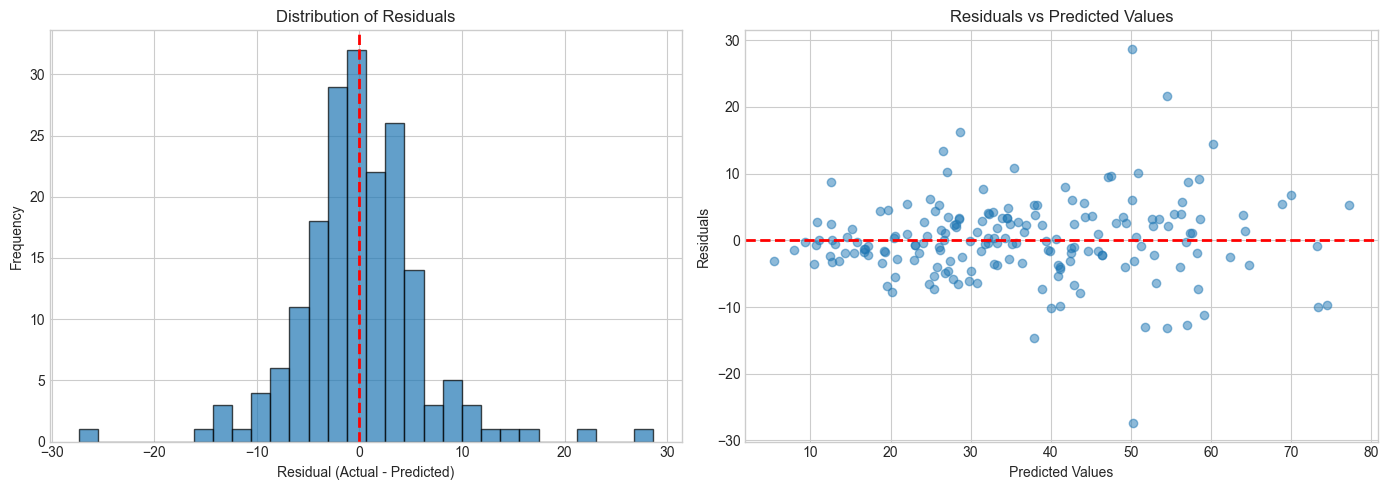

Residual mean (should be ~0): 0.11
Residual std: 6.07


In [29]:
# Residual analysis
residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residual distribution (should be roughly normal, centered at 0)
axes[0].hist(residuals, bins=30, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Residuals')

# Residuals vs Predicted (should show no pattern)
axes[1].scatter(y_pred, residuals, alpha=0.5)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Predicted Values')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residuals vs Predicted Values')

plt.tight_layout()
plt.show()

print(f"Residual mean (should be ~0): {residuals.mean():.2f}")
print(f"Residual std: {residuals.std():,.2f}")

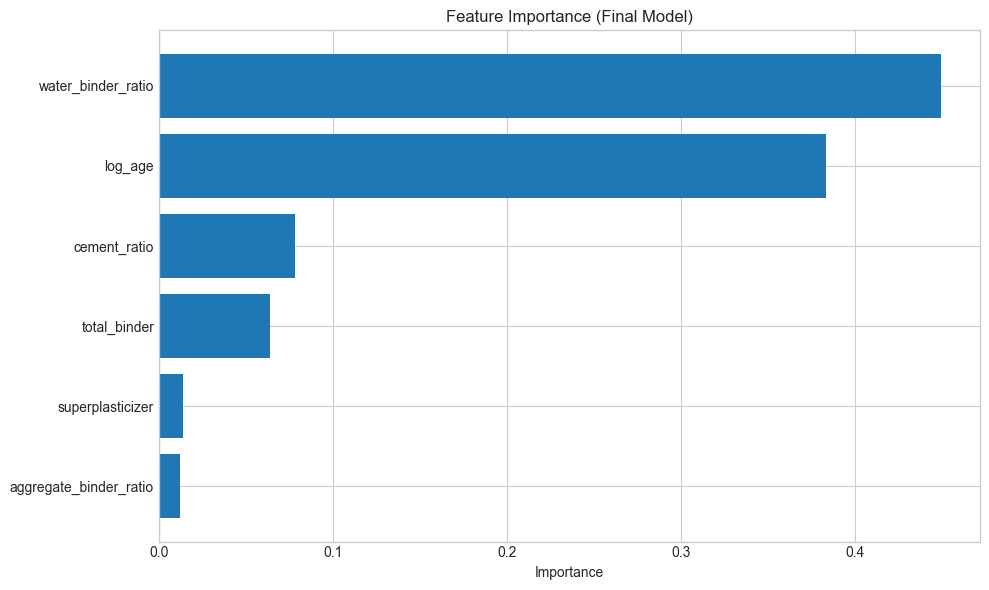

In [30]:
# Feature importance for final model (with selected features)
if hasattr(final_model, 'feature_importances_'):
    final_importance = pd.DataFrame({
        'Feature': SELECTED_FEATURES,
        'Importance': final_model.feature_importances_
    }).sort_values('Importance', ascending=True)
    
    plt.figure(figsize=(10, 6))
    plt.barh(final_importance['Feature'], final_importance['Importance'])
    plt.xlabel('Importance')
    plt.title('Feature Importance (Final Model)')
    plt.tight_layout()
    plt.show()
elif hasattr(final_model, 'coef_'):
    final_importance = pd.DataFrame({
        'Feature': SELECTED_FEATURES,
        'Coefficient': final_model.coef_
    }).sort_values('Coefficient', key=abs, ascending=True)
    
    plt.figure(figsize=(10, 6))
    colors = ['green' if c > 0 else 'red' for c in final_importance['Coefficient']]
    plt.barh(final_importance['Feature'], final_importance['Coefficient'], color=colors)
    plt.xlabel('Coefficient')
    plt.title('Feature Coefficients (Final Model)')
    plt.tight_layout()
    plt.show()

## Section 12: Save Model and Artifacts

In [31]:
# Create a new scaler fitted only on selected features
final_scaler = StandardScaler()
X_train_final = X_train[SELECTED_FEATURES]
X_test_final = X_test[SELECTED_FEATURES]

# Fit scaler on training data only (no data leakage)
X_train_final_scaled = final_scaler.fit_transform(X_train_final)
X_test_final_scaled = final_scaler.transform(X_test_final)

# Retrain final model using the correctly-scaled data so the saved model
# and saved scaler are consistent with each other
final_model.fit(X_train_final_scaled, y_train)

# Save the best model
model_path = '../models/regression_model.pkl'
joblib.dump(final_model, model_path)
print(f"Model saved to {model_path}")

# Save the scaler (fitted on selected features only)
scaler_path = '../models/regression_scaler.pkl'
joblib.dump(final_scaler, scaler_path)
print(f"Scaler saved to {scaler_path}")

# Save feature names (the selected features for Streamlit app)
features_path = '../models/regression_features.pkl'
joblib.dump(SELECTED_FEATURES, features_path)
print(f"Features saved to {features_path}")

Model saved to ../models/regression_model.pkl
Scaler saved to ../models/regression_scaler.pkl
Features saved to ../models/regression_features.pkl


In [32]:
# Verify saved model works
loaded_model = joblib.load(model_path)
loaded_scaler = joblib.load(scaler_path)
loaded_features = joblib.load(features_path)

# Test prediction — use loaded_scaler (the 6-feature scaler) to match real app usage
test_sample = X_test[loaded_features].iloc[[0]]
test_sample_scaled = loaded_scaler.transform(test_sample)
test_pred = loaded_model.predict(test_sample_scaled)

print(f"\nModel verification:")
print(f"Features used: {loaded_features}")
print(f"Sample input: {test_sample.values[0]}")
print(f"Predicted: {test_pred[0]:,.2f}")
print(f"Actual: {y_test.iloc[0]:,.2f}")
print(f"\nModel saved and verified successfully!")


Model verification:
Features used: ['log_age', 'water_binder_ratio', 'total_binder', 'cement_ratio', 'aggregate_binder_ratio', 'superplasticizer']
Sample input: [3.36729583e+00 3.25097797e-01 4.85700000e+02 8.00082355e-01
 3.66028413e+00 1.21000000e+01]
Predicted: 52.87
Actual: 50.70

Model saved and verified successfully!


## Section 13: Binning Strategy for Classification

**IMPORTANT:** Before you start Notebook 03, you need to send your binning strategy to Abishek on Slack for approval by **Feb 15**.

### Analyze Target Distribution

In [33]:
# Look at target distribution to help decide binning
print(f"Target: {TARGET}")
print(f"\nDescriptive Statistics:")
print(y.describe())

print(f"\nPercentiles:")
for p in [10, 25, 33, 50, 67, 75, 90]:
    print(f"{p}th percentile: {y.quantile(p/100):,.2f}")

Target: concrete_compressive_strength

Descriptive Statistics:
count    919.000000
mean      34.432448
std       16.349663
min        2.330000
25%       22.440000
50%       33.190000
75%       44.290000
max       82.600000
Name: concrete_compressive_strength, dtype: float64

Percentiles:
10th percentile: 13.51
25th percentile: 22.44
33th percentile: 25.51
50th percentile: 33.19
67th percentile: 40.15
75th percentile: 44.29
90th percentile: 56.62


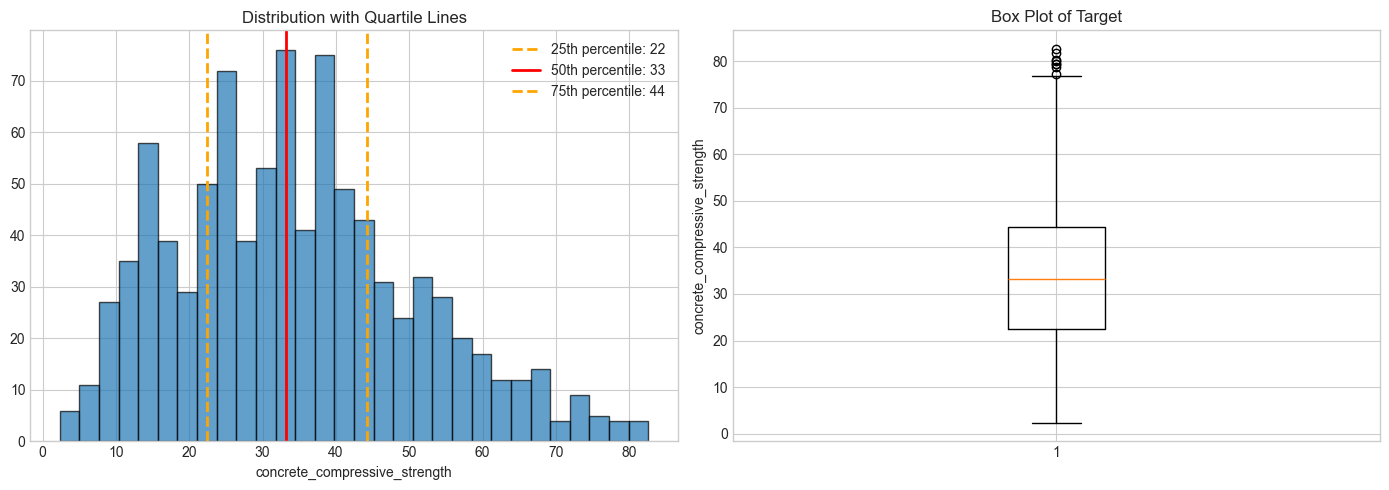

In [34]:
# Visualize potential binning strategies
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with quartile lines
axes[0].hist(y, bins=30, edgecolor='black', alpha=0.7)
for p, color, style in [(25, 'orange', '--'), (50, 'red', '-'), (75, 'orange', '--')]:
    axes[0].axvline(y.quantile(p/100), color=color, linestyle=style, linewidth=2,
                     label=f'{p}th percentile: {y.quantile(p/100):,.0f}')
axes[0].set_xlabel(TARGET)
axes[0].set_title('Distribution with Quartile Lines')
axes[0].legend()

# Box plot
axes[1].boxplot(y)
axes[1].set_ylabel(TARGET)
axes[1].set_title('Box Plot of Target')

plt.tight_layout()
plt.show()

### Proposed Binning Strategy

*Complete this section and send to Abishek on Slack by Feb 15:*

**1. How many categories will you create?**

[Your answer - e.g., 3 categories: Low, Medium, High]

3 categories: **Low**, **Medium**, **High**

Preview of binned target (using quartiles):

| Category | Count | Percentage |
|----------|-------|------------|
| Low      | 231   | 25.1%      |
| Medium   | 458   | 49.8%      |
| High     | 230   | 25.0%      |

**2. What are your bin thresholds?**

- **Low:** < 22.44 MPa (below 25th percentile)
- **Medium:** 22.44 – 44.29 MPa (between 25th and 75th percentile)
- **High:** > 44.29 MPa (above 75th percentile)

These thresholds align with the 25th and 75th percentiles, producing a near-balanced class distribution (25% / 50% / 25%).

In practice, these map to real engineering grades: Low corresponds to concrete unsuitable for structural use, Medium covers general construction (slabs, walls), and High corresponds to structural/load-bearing applications where strength > 44 MPa is typically required by building codes.

**3. Why does this binning make sense for your problem?**

[Your answer - explain the domain reasoning. Why are these meaningful categories?]

Quartile-based binning is appropriate here for two reasons:

- **Statistical balance:** The 25th/75th percentile split produces a roughly balanced dataset (25% / 50% / 25%), avoiding severe class imbalance that would bias the classifier.

- **Domain meaning:** The thresholds correspond to real-world concrete strength grades used in civil engineering. Low-strength concrete (< 22 MPa) is typically only suitable for non-structural fills. Medium-strength (22–44 MPa) covers most general construction applications (slabs, beams, walls). High-strength (> 44 MPa) is required for structural and load-bearing elements per standard building codes.

In [35]:
# Preview your binning
def create_bins_preview(y, strategy='quartile'):
    if strategy == 'quartile':
        bins = [y.min()-1, y.quantile(0.25), y.quantile(0.75), y.max()+1]
        labels = ['Low', 'Medium', 'High']
    elif strategy == 'tertile':
        bins = [y.min()-1, y.quantile(0.33), y.quantile(0.67), y.max()+1]
        labels = ['Low', 'Medium', 'High']
    # Add your custom strategy here if needed
    
    return pd.cut(y, bins=bins, labels=labels)

# Preview with quartile binning
y_binned = create_bins_preview(y, 'quartile')
print("Preview of binned target (using quartiles):")
print(y_binned.value_counts().sort_index())
print(f"\nPercentages:")
print((y_binned.value_counts(normalize=True) * 100).round(1).sort_index())

Preview of binned target (using quartiles):
concrete_compressive_strength
Low       231
Medium    458
High      230
Name: count, dtype: int64

Percentages:
concrete_compressive_strength
Low       25.1
Medium    49.8
High      25.0
Name: proportion, dtype: float64


---

## Summary

### What You Accomplished
- [ ] Loaded and prepared cleaned data
- [ ] Split data into train and test sets
- [ ] Scaled features appropriately
- [ ] Built a baseline model
- [ ] Tried multiple model types
- [ ] Performed cross-validation
- [ ] Selected top 4-8 features
- [ ] Compared and selected best model
- [ ] Analyzed model performance (residuals, feature importance)
- [ ] Saved model, scaler, and feature list
- [ ] Planned binning strategy for classification

### Key Results

**Best Model:** [Model name]

**Selected Features:** [List them]

**Test R²:** [Value]

**Test RMSE:** [Value]

**Improvement over baseline:** [Percentage or description]

---

---

## Checkpoint 3 Submission Instructions

**Congratulations!** You've completed Checkpoint 3 (Regression Model).

### Step 1: Save This Notebook
- File -> Save (or Ctrl+S / Cmd+S)

### Step 2: Send Binning Strategy to Abishek
- Message Abishek on Slack with your binning strategy
- Include: number of categories, thresholds, and justification

### Step 3: Commit to GitHub

```bash
# Stage your changes
git add notebooks/02_regression_model.ipynb
git add models/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 3: Regression model with feature selection"

# Push to GitHub
git push
```

### Step 4: Submit to Canvas
1. Go to the Checkpoint 3 assignment on Canvas
2. Submit the link to your GitHub repository

---

## Next Steps

1. **Wait for binning approval** from Abishek
2. Move on to **Notebook 03: Classification Model**

---